# Student Performance Analysis using Python

## Data Loading

In [1]:
import pandas as pd

df = pd.read_csv('StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Data Analysis

In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## Feature Engineering

In [3]:
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [4]:
def performance(score):
    if score >= 75:
        return 'High'
    elif score >= 50:
        return 'Medium'
    else:
        return 'Low'

df['performance'] = df['average_score'].apply(performance)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,performance
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,Medium
1,female,group C,some college,standard,completed,69,90,88,82.333333,High
2,female,group B,master's degree,standard,none,90,95,93,92.666667,High
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,Low
4,male,group C,some college,standard,none,76,78,75,76.333333,High


## Visualizations

Matplotlib is building the font cache; this may take a moment.


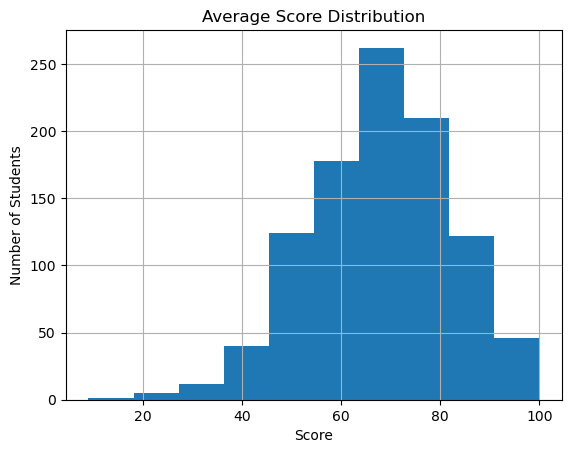

In [5]:
import matplotlib.pyplot as plt

df['average_score'].hist()
plt.title('Average Score Distribution')
plt.xlabel('Score')
plt.ylabel('Number of Students')
plt.show()

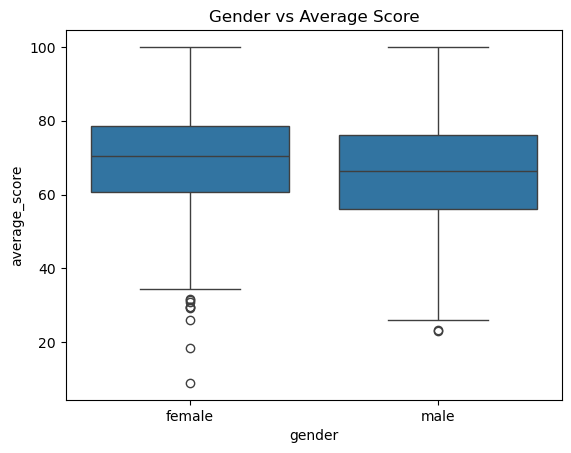

In [6]:
import seaborn as sns

sns.boxplot(x='gender', y='average_score', data=df)
plt.title('Gender vs Average Score')
plt.show()


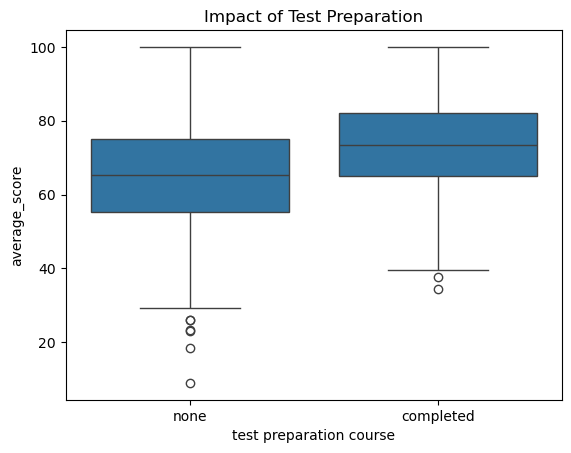

In [7]:
sns.boxplot(x='test preparation course', y='average_score', data=df)
plt.title('Impact of Test Preparation')
plt.show()

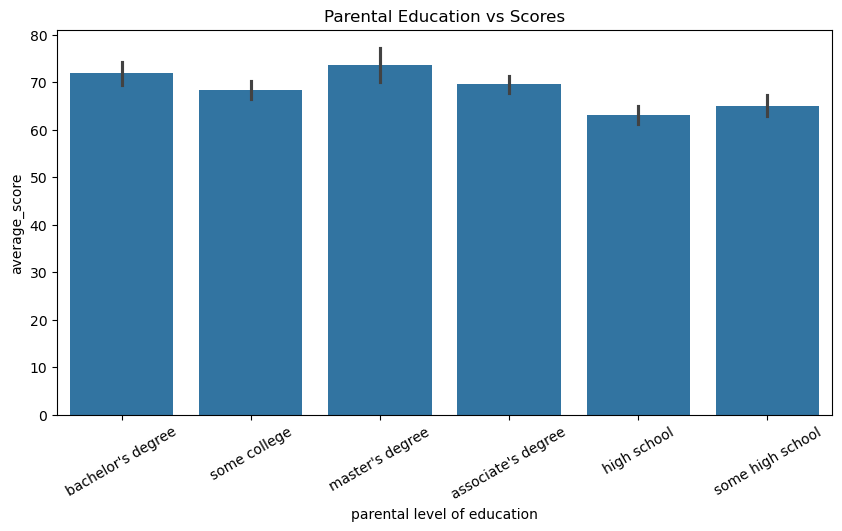

In [8]:
plt.figure(figsize=(10,5))
sns.barplot(x='parental level of education', y='average_score', data=df)
plt.xticks(rotation=30)
plt.title('Parental Education vs Scores')
plt.show()

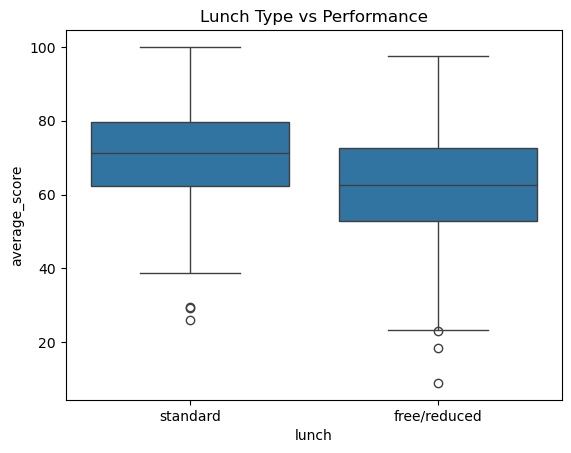

In [9]:
sns.boxplot(x='lunch', y='average_score', data=df)
plt.title('Lunch Type vs Performance')
plt.show()

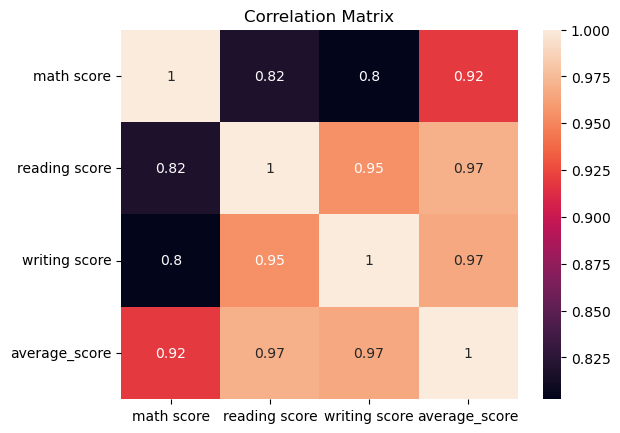

In [10]:
corr = df[['math score','reading score','writing score','average_score']].corr()

sns.heatmap(corr, annot=True)
plt.title('Correlation Matrix')
plt.show()

## Insights

Students who completed the test preparation course scored higher on average.
Reading and writing scores are highly correlated.
Gender differences in performance are minimal.
Students with standard lunch tend to perform better.
Parental education shows moderate impact on student scores.

## Machine Learning Model

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features (inputs)
X = df[['reading score','writing score']]

# Target (what we predict)
y = df['math score']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Accuracy
print("Model Accuracy:", model.score(X_test, y_test))

Model Accuracy: 0.6336638658286351


## Conclusion

Student performance is influenced by multiple factors such as test preparation, lunch type, and parental education.
Reading and writing scores have a strong relationship with math scores.
Students who completed test preparation performed significantly better.
The dataset shows that academic performance can be predicted using related subject scores.